# Calibrating the decay constant k for the API formula

## Libraries

In [19]:
import ee
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

## Initialize Earth Engine

In [20]:
ee.Authenticate() 
ee.Initialize(project='gen-lang-client-0375557253')

## Part 1: Extract the Data from Earth Engine

### 1. Define Area of Interest (Galați County)

In [21]:

galati = ee.FeatureCollection("FAO/GAUL/2015/level1") \
    .filter(ee.Filter.eq('ADM1_NAME', 'Galati'))

### 2. Define the Calibration Period (A full year captures wet/dry seasonality)

In [22]:
start_date = '2022-01-01'
end_date = '2022-12-31'

### 3. Fetch CHIRPS Daily Precipitation

In [23]:

chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
    .filterBounds(galati) \
    .filterDate(start_date, end_date)

### 4. Fetch NASA USDA SMAP Soil Moisture (Surface Soil Moisture band 'sm_surface')

In [24]:

smap = ee.ImageCollection("NASA/SMAP/SPL4SMGP/008") \
    .filterBounds(galati) \
    .filterDate(start_date, end_date) \
    .select('sm_surface')

In [25]:
# # Helper function to extract regional mean timeseries
# def extract_timeseries(collection, band_name):
#     def get_mean(img):
#         mean_val = img.reduceRegion(
#             reducer=ee.Reducer.mean(),
#             geometry=galati.geometry(),
#             scale=10000, # 10km scale is fine for regional averages
#             maxPixels=1e9
#         ).get(band_name)
#         return ee.Feature(None, {
#             'date': img.date().format('YYYY-MM-dd'),
#             'value': mean_val
#         })
#     # Map function and fetch data to client side
#     features = collection.map(get_mean).getInfo()['features']
    
#     # Convert to Pandas DataFrame
#     df = pd.DataFrame([f['properties'] for f in features])
#     df['date'] = pd.to_datetime(df['date'])
#     df = df.set_index('date').dropna()
#     df.columns = [band_name]
#     return df

# Helper function to extract regional mean timeseries (MEMORY OPTIMIZED)
def extract_timeseries(collection, band_name):
    # 1. Get a list of dates for the collection
    def get_date(img):
        return ee.Feature(None, {'date': img.date().format('YYYY-MM-dd')})
    
    dates_info = collection.map(get_date).getInfo()['features']
    dates = [f['properties']['date'] for f in dates_info]
    
    # 2. Convert the entire ImageCollection into a single Image with 365 bands
    # This is a massive memory optimization for GEE
    multi_band_image = collection.toBands()
    
    # 3. Perform a single reduceRegion on the multi-band image
    # We increase the scale (e.g., 20000m = 20km) to further save memory. 
    # For a county-wide average of a 10km dataset like SMAP, 20km is perfectly fine.
    mean_dict = multi_band_image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=galati.geometry(),
        scale=20000, 
        maxPixels=1e9
    ).getInfo()
    
    # 4. Reconstruct the Pandas DataFrame
    # GEE names the bands like "20220101_precipitation", we just want the values in order
    values = list(mean_dict.values())
    
    df = pd.DataFrame({
        'date': pd.to_datetime(dates),
        band_name: values
    })
    
    df = df.set_index('date').sort_index()
    return df

In [26]:
print("Fetching CHIRPS and SMAP data from Earth Engine... (this takes a few seconds)")

#Extract both datasets
df_rain = extract_timeseries(chirps, 'precipitation')
df_soil = extract_timeseries(smap, 'sm_surface')

#Merge them into a single timeline, filling missing SMAP days using interpolation
df = df_rain.join(df_soil, how='outer')
df['sm_surface'] = df['sm_surface'].interpolate(method='linear') # Fill 3-day SMAP gaps
df['precipitation'] = df['precipitation'].fillna(0)

print("Data extraction complete! DataFrame shape:", df.shape)

Fetching CHIRPS and SMAP data from Earth Engine... (this takes a few seconds)
Data extraction complete! DataFrame shape: (2912, 2)


## Part 2: Calibrate the Decay Constant ($k$)

In [28]:
# Create an array of candidate k values to test
k_candidates = np.arange(0.80, 0.99, 0.01)
correlations = []

print("Calibrating decay constant (k)...")

# Loop through every candidate k
for k in k_candidates:
    api_values = []
    current_api = 0
    
    # Calculate the API timeseries for this specific k
    for rain in df['precipitation']:
        current_api = (current_api * k) + rain
        api_values.append(current_api)
        
    # Store the calculated API temporarily
    df['API_temp'] = api_values
    
    # Calculate the Pearson correlation between our calculated API and actual SMAP soil moisture
    corr, _ = pearsonr(df['API_temp'], df['sm_surface'])
    correlations.append(corr)

# Find the k that produced the highest correlation
best_index = np.argmax(correlations)
best_k = k_candidates[best_index]
best_corr = correlations[best_index]

print(f"\n✅ CALIBRATION SUCCESSFUL!")
print(f"The optimal decay constant for Galați is: k = {best_k:.2f}")
print(f"Correlation with SMAP Soil Moisture: r = {best_corr:.3f}")

Calibrating decay constant (k)...

✅ CALIBRATION SUCCESSFUL!
The optimal decay constant for Galați is: k = 0.91
Correlation with SMAP Soil Moisture: r = 0.215


In [ ]:

# --- Plot the Results for your Thesis ---
plt.figure(figsize=(10, 5))
plt.plot(k_candidates, correlations, marker='o', color='#2c7fb8', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k:.2f}')
plt.title('API Decay Constant ($k$) vs. SMAP Soil Moisture Correlation', fontsize=14)
plt.xlabel('Decay Constant ($k$)', fontsize=12)
plt.ylabel('Pearson Correlation Coefficient ($r$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

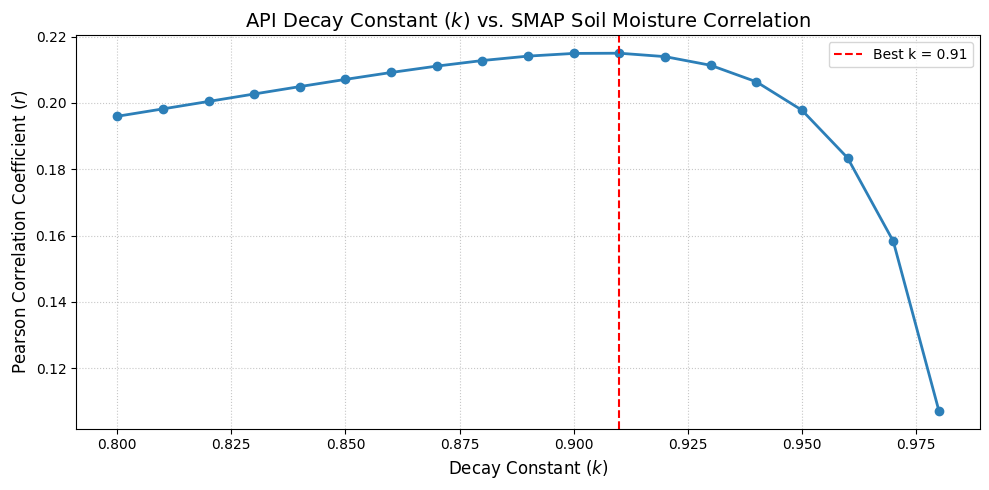